# Caso 5 - Predicción de precipitaciones en el futuro usando modelos de series de tiempo
 En este caso trabajaremos con los datos históricos de precipitaciones de una estación hidrológica. Veremos como implementar modelos clásicos de predicción de series de tiempo como ARIMA; y herramientas modernas como Prophet para realizar predicciones a corto y mediano plazo. Además, aplicaremos curvas de autocorrelación para analizar la dependencia temporal de las series y mejorar la elección de parámetros. Este caso permitirá comparar el comportamiento de dos fenómenos distintos a través del enfoque común de análisis de series de tiempo.

## Resultado previsto de aprendizaje
Al finalizar este caso el estudiante reforzará su capacidad para analizar y compilar datos provenientes de diferentes bases de datos. También estará en capacidad de utilizar las librerías `statsmodels` y `prophet` para hacer predicciones del comportamiento de series de tiempo.

_________

## Contexto del Problema

- Usted es el encargado de monitorear fenómenos climáticos y desea hacer un estudio del comportamiento histórico de las precipitaciones en estaciones meteorológicas de la región y quiere responder la siguiente pregunta. ¿Es posible usar el comportamiento histórico para predecir el futuro de las precipitaciones?



Iniciamos importando las librerías que necesitaremos para llevar a cabo el caso

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from prophet import Prophet # Se debe instalar previamente la librería prophet
from prophet.diagnostics import cross_validation, performance_metrics
import warnings; warnings.filterwarnings('ignore')  
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

sns.set_context('paper')

c:\UniSabana\fundamentos\AdproUv\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Cargando los datos

Para nuestro primer caso usaremos la misma base de datos de precipitaciones trabajada en el caso anterior

In [2]:
prec = pd.read_csv('data/base_precipitaciones_unificada.csv')

A diferencia de los casos anteriores, en este caso agregamos un componente adicional a la ruta de acceso a la base de datos. Al comienzo de la dirección usamos '..', lo que indica que debemos retroceder una carpeta desde la ubicación actual. Desde allí, seguimos la ruta correspondiente al caso de estudio anterior para llegar nuevamente a la misma base de datos.

Ahora recordemos cómo luce nuestra base de datos de precipitaciones en la región:

In [3]:
prec.head(10)

,AÑO,MES,PRECIPITACION,FECHA,NOMBRE,CODIGO,LONGITUD,LATITUD
0,1932,1,59.8,1932-01,ZIPAQUIRÁ,2120074,5.01,74.0
1,1932,2,19.4,1932-02,ZIPAQUIRÁ,2120074,5.01,74.0
2,1932,3,40.3,1932-03,ZIPAQUIRÁ,2120074,5.01,74.0
3,1932,4,49.6,1932-04,ZIPAQUIRÁ,2120074,5.01,74.0
4,1932,5,138.8,1932-05,ZIPAQUIRÁ,2120074,5.01,74.0
5,1932,6,34.2,1932-06,ZIPAQUIRÁ,2120074,5.01,74.0
6,1932,7,NaN,1932-07,ZIPAQUIRÁ,2120074,5.01,74.0
7,1932,8,NaN,1932-08,ZIPAQUIRÁ,2120074,5.01,74.0
8,1932,9,NaN,1932-09,ZIPAQUIRÁ,2120074,5.01,74.0
9,1932,10,NaN,1932-10,ZIPAQUIRÁ,2120074,5.01,74.0


En este caso, lo que esperamos es llegar a una predicción de las precipitaciones para una estación meteorológica específica. Hagamos el análisis con la misma estación que escogimos en nuestro caso anterior, ya que tiene muchos datos

In [4]:
ramada = prec[prec['CODIGO'] == 2120516]

In [5]:
# Re-formateamos la fecha para que sea un objeto datetime
ramada['FECHA']= pd.to_datetime(ramada['FECHA'])

Analicemos ahora gráficamente las precipitaciones en la estación La Ramada

In [6]:
import plotly.express as px

fig = px.line(ramada, x='FECHA', y='PRECIPITACION', title='Precipitaciones en la estación La Ramada')
fig.update_layout(
    xaxis_title='Fecha',
    yaxis_title='Precipitaciones',
    template='plotly_white',
    width=800,
    height=400,
)
fig.show()

Como vemos, la serie tiene una interrupción alrededor de 2023. Enfoquémonos en la última sección continua de la serie

In [7]:
# Filtrar la base de datos posterior al año 2003 y graficar usando plotly
ramada = ramada[ramada['FECHA'] > '2003-01-01'].dropna(subset=['PRECIPITACION'])

fig = px.line(ramada, x='FECHA', y='PRECIPITACION', title='Precipitaciones en la estación La Ramada (2003-2023)')
fig.update_layout(
    xaxis_title='Fecha',
    yaxis_title='Precipitaciones',
    template='plotly_white',
    width=800,
    height=400,
)

___
#### Ejercicio 1
Grafique las precipitaciones históricas de la estación `Zipaquirá` 
___

In [11]:
zipaquira = prec[prec['CODIGO'] == 2120074]

zipaquira['FECHA']= pd.to_datetime(zipaquira['FECHA'])

import plotly.express as px

fig = px.line(zipaquira, x='FECHA', y='PRECIPITACION', title='Precipitaciones en la estación Zipaquira')
fig.update_layout(
    xaxis_title='Fecha',
    yaxis_title='Precipitaciones',
    template='plotly_white',
    width=800,
    height=400,
)
fig.show()

In [13]:
# Filtrar la base de datos posterior al año 1993 y graficar usando plotly
zipaquira = zipaquira[zipaquira['FECHA'] > '1993-01-01'].dropna(subset=['PRECIPITACION'])

fig = px.line(zipaquira, x='FECHA', y='PRECIPITACION', title='Precipitaciones en la estación Zipaquira (1993-2023)')
fig.update_layout(
    xaxis_title='Fecha',
    yaxis_title='Precipitaciones',
    template='plotly_white',
    width=800,
    height=400,
)

# Prediciendo el comportamiento futuro - ARIMA
El modelo ARIMA es uno de los más conocidos para hacer predicciones de series de tiempo. El modelo arima se conoce por tener 3 parámetros que determinan su comportamiento:

-	AR (Autoregresivo - p): Esta parte del modelo asume que el valor actual de la serie puede ser predicho utilizando una combinación lineal de sus valores pasados (lags). El parámetro 'p' indica cuántos lags (observaciones pasadas) se incluyen en el modelo.
-	I (Integrado - d): Las series de tiempo del mundo real raramente son estacionarias, es decir, sus propiedades estadísticas como la media y la varianza cambian con el tiempo. La componente 'Integrada' aborda esto mediante la diferenciación de la serie (calcular la diferencia entre observaciones consecutivas) una o más veces para hacerla estacionaria. El parámetro 'd' representa el número de veces que la serie necesita ser diferenciada. ARIMA asume que la serie es estacionaria después de la diferenciación.
-	MA (Media Móvil - q): Esta parte modela la dependencia entre una observación y el error residual de un modelo de media móvil aplicado a observaciones anteriores. No se refiere a una simple media móvil para suavizar, sino que utiliza los errores de predicción pasados para mejorar el pronóstico actual. El parámetro 'q' indica cuántos errores de pronóstico pasados se incluyen en el modelo.


# Primer paso: Determinando el parámetro $d$
En la práctica el parámetro $d$ se determina como el número de veces que debo diferenciar mi serie de tiempo antes de que la serie se convierta en una serie estacionaria. El término *diferenciar* se refiere en este caso a reemplazar la serie de tiempo original por la serie de diferencias $\hat{y_{i}} = y_{i}-y_{i-1}$.

Entonces lo primero que debemos determinar es si nuestra serie original es estacionaria o no, en caso negativo, debemos determinar cuántas veces debemos diferenciarla para que lo sea

In [14]:
# Dickey-Fuller test para verificar estacionariedad
result = adfuller(ramada['PRECIPITACION'].dropna())
print(f'Estadistico: {result[0]}')
print(f'p-valor: {result[1]}')

Estadistico: -3.374909225067338
p-valor: 0.01184453819672962


Como se observa, la probabilidad de observar los datos asumiendo que la serie no fuera estacionaria (p-valor) es de apenas el 1.18%. De manera que con confianza podemos asumir que la serie es estacionaria. Esto implica que el parámetro $d=0$. 

El p-valor es pequeño, por lo que se puede descartar la hipótesis nula que dice que la serie es no estacionaria, por ende es estacionaria.

## Gráficas de ACF y PACF para determinar p y q

### Introducción

Las gráficas de autocorrelación (ACF) y autocorrelación parcial (PACF) son herramientas fundamentales en el análisis de series de tiempo. Permiten comprender las dependencias temporales en los datos y son esenciales para construir modelos como ARIMA.

---

### Teoría detrás de ACF y PACF

#### Autocorrelación (ACF)

La **autocorrelación** mide el grado de relación entre una serie de tiempo y sus propios valores retardados (*lags*). Se calcula como:

$$
\rho_k = \frac{\sum_{t=k+1}^{T}(y_t - \bar{y})(y_{t-k} - \bar{y})}{\sum_{t=1}^{T}(y_t - \bar{y})^2}
$$

Donde:
- $ \rho_k $: Autocorrelación en el lag $k$.
- $ y_t $: Valor de la serie en el tiempo $t$.
- $ \bar{y} $: Media de la serie.
- $ T $: Número total de observaciones.

En la gráfica de ACF:
- Los picos significativos indican la presencia de autocorrelación.
- Un patrón decreciente indica que la serie puede ser un proceso integrado.

#### Autocorrelación Parcial (PACF)

La **autocorrelación parcial** mide la correlación entre $y_t$ y $y_{t-k}$ eliminando el efecto de los retardos intermedios $y_{t-1}, y_{t-2}, \dots, y_{t-(k-1)}$. Esto permite aislar la influencia directa de un retardo específico.

Matemáticamente, se deriva resolviendo un sistema de ecuaciones lineales basado en la autocorrelación:

$$
\phi_{kk} = \text{cor}(y_t, y_{t-k} \mid y_{t-1}, y_{t-2}, ..., y_{t-(k-1)})
$$

En la gráfica de PACF:
- Los picos significativos ayudan a determinar el orden autoregresivo ($p$) del modelo ARIMA.

---

### Límite de Significancia Estadística

En las gráficas de ACF y PACF, las barras incluyen un límite de confianza. Esto se calcula como:

$$
\pm \frac{1.96}{\sqrt{T}}
$$

Donde $T$ es el número total de observaciones. 

- Cualquier barra que exceda este límite se considera estadísticamente significativa al nivel del 5%.
- Si las barras caen dentro de los límites, la correlación puede ser atribuida al azar.


---

### Interpretación de las Gráficas

#### ACF:
1. **Disminución gradual:** Indica que la serie puede ser un proceso integrado (necesita diferenciación para ser estacionaria).
2. **Picos repetitivos:** Sugieren estacionalidad o periodicidad en la serie.
3. **Patrón de cola larga:** Común en procesos de tipo MA ($q$) o integrados.

#### PACF:
1. **Pocos picos significativos:** Identifican el orden $p$ en modelos ARIMA.
2. **Disminución abrupta:** Característico de un modelo AR puro.
A continuación, aplicamos estos conceptos a nuestra serie de tiempo

Lo primero a revisar es la estacionariedad, en caso que nuestros datos no tengan esta característica es necesario realizar las diferenciaciones necesarias $d$ hasta que se cumpla esta condición, debido a que nuestros datos de precipitaciones son estacionarios, no es necesario realizar este paso, en nuestro siguiente caso veremos cómo se aplica esto.

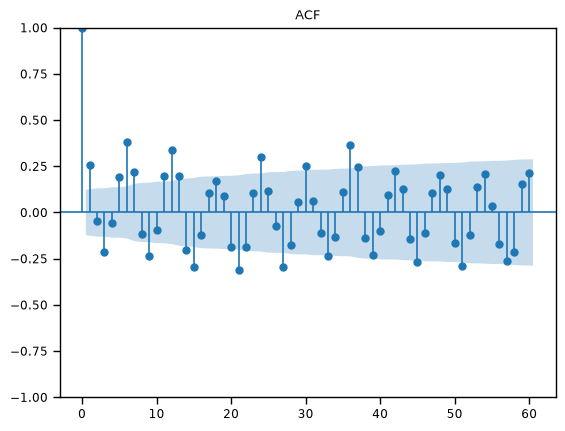

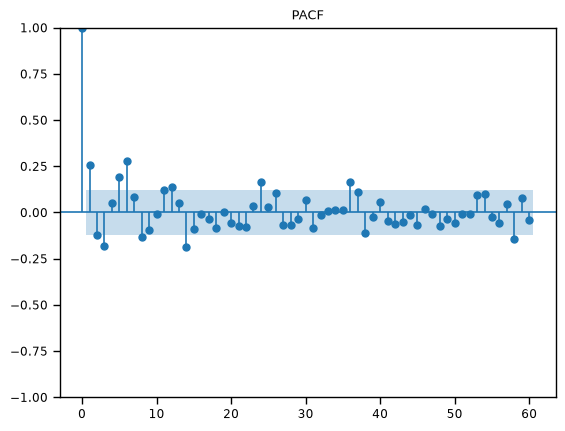

In [15]:
# Graficando ACF y PACF, .los paquetes ACF y PACF fueron previamente importados en nuestra celda de código inicial
plot_acf(ramada['PRECIPITACION'].dropna(), lags=60, title="ACF")
plt.show()
plot_pacf(ramada['PRECIPITACION'].dropna(), lags=60, title="PACF")
plt.show()

La región sombreada en las dos curvas representa la zona en la que la significancia estadística de las correlaciones cae por debajo de un 5%. En ambos casos podemos ver oscilaciones en la correlación, relacionadas con la fuerta estacionalidad en la serie de tiempo. Aunque en ambos casos, incluso con 5 años (60 meses) de retraso hay correlaciones significativas, vamos a restringir el modelo a 3 años (36). Esto implica entonces que los valores de nuestro modelo serán:

- $d=0$, la serie es estacionaria originalmente
- $q=36$, por los resultados de la curva ACF
- $p=36$, por los resultados de la curva PACF

**¡OJO!Recuerde que el análisis ACF y PACF debe hacerse sobre series de tiempo estacionarias**

___
#### Ejercicio 2
Realice el análisis de ACF y PACF para las precipitaciones de la estación `Zipaquirá`. Tenga en cuenta que primero se debe evaluar su estacionariedad, por lo que es necesario realizar el test de Dickey-Fuller.
___

In [49]:
# Dickey-Fuller test para verificar estacionariedad
result = adfuller(zipaquira['PRECIPITACION'].dropna())
print("Estadístico ADF:", result[0])
print("p-value:", result[1])
print("Número de rezagos:", result[2])
print("Número de observaciones:", result[3])
print("Valores críticos:", result[4])

Estadístico ADF: -5.01719361568175
p-value: 2.051841037623177e-05
Número de rezagos: 13
Número de observaciones: 350
Valores críticos: {'1%': np.float64(-3.4491725955218655), '5%': np.float64(-2.8698334971428574), '10%': np.float64(-2.5711883591836733)}


In [ ]:
# SI NO FUERA ESTACIONARIA SE HACE ESTO
# from statsmodels.tsa.seasonal import seasonal_decompose 

# # Decompose the Zipaquira time series
# decomposition = seasonal_decompose(zipaquira['PRECIPITACION'], model='additive', period=12)

# # Extract the components
# zipa_trend = decomposition.trend
# zipa_seasonal = decomposition.seasonal
# zipa_residual = decomposition.resid

# zipaquira['tendencia'] = zipa_trend
# zipaquira['estacional'] = zipa_seasonal
# zipaquira['residuo'] = zipa_residual

# zipaquira['diferenciada'] = zipaquira['PRECIPITACION'].diff().dropna()

# zipaquira.head(10)

#decomposition.plot()

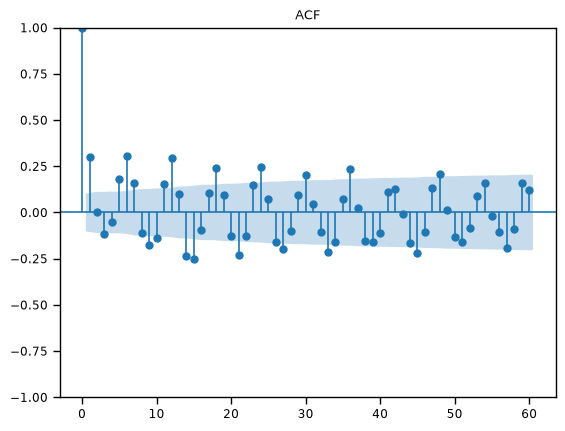

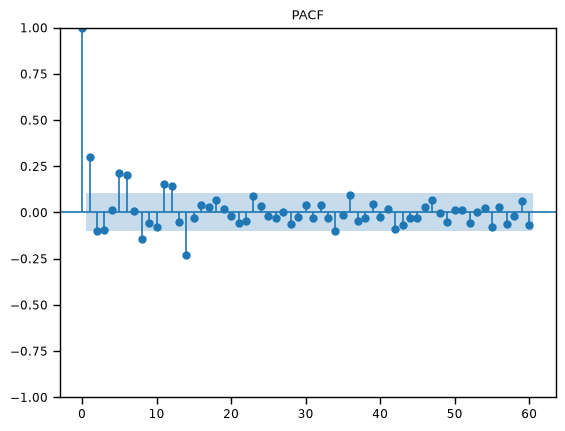

In [50]:
# Graficando ACF y PACF, .los paquetes ACF y PACF fueron previamente importados en nuestra celda de código inicial
plot_acf(zipaquira['PRECIPITACION'].dropna(), lags=60, title="ACF")
plt.show()
plot_pacf(zipaquira['PRECIPITACION'].dropna(), lags=60, title="PACF")
plt.show()

La región sombreada en las dos curvas representa la zona en la que la significancia estadística de las correlaciones cae por debajo de un 5%. En ambos casos podemos ver oscilaciones en la correlación, relacionadas con la fuerta estacionalidad en la serie de tiempo. Vemos que con 5 años (60 meses) de retraso solo los primeros 12 meses tiene correlacciones significativas , vamos a restringir el modelo a 1 año (12). Esto implica entonces que los valores de nuestro modelo serán:

- $d=0$, la serie es estacionaria originalmente
- $q=12$, por los resultados de la curva ACF
- $p=12$, por los resultados de la curva PACF

## Aplicando ARIMA a nuestros datos

Para aplicar ARIMA lo primero que haremos será simplificar nuestros datos para concentrarnos en la información relevante: la fecha y la precipitación

In [30]:
ramada_predict = ramada[['FECHA', 'PRECIPITACION']].rename(columns={'FECHA': 'ds', 'PRECIPITACION': 'y'})
ramada_predict.set_index('ds', inplace=True)
ramada_predict

,y
ds,
2003-02-01,35.2
2003-03-01,78.0
2003-04-01,76.2
2003-05-01,30.6
2003-06-01,50.9
...,...
2023-12-01,50.3
2024-01-01,4.2
2024-02-01,18.1


Ahora procedemos a ajustar el modelo sobre nuestros datos

In [51]:
# Ajustar un modelo ARIMA
model = ARIMA(ramada_predict['y'], order=(36, 0,36))  # p=36, d=0, q=36
fitted_model = model.fit()

# Resumen del modelo
print(fitted_model.summary())

c:\UniSabana\fundamentos\AdproUv\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\UniSabana\fundamentos\AdproUv\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\UniSabana\fundamentos\AdproUv\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\UniSabana\fundamentos\AdproUv\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\UniSabana\fundamentos\AdproUv\.venv\Lib\site-packages\statsmodels\tsa\st

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  255
Model:               ARIMA(36, 0, 36)   Log Likelihood               -1276.655
Date:              lun., 27 jul. 2026   AIC                           2701.310
Time:                        22:22:54   BIC                           2963.364
Sample:                    02-01-2003   HQIC                          2806.719
                         - 04-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         73.6270      8.114      9.074      0.000      57.724      89.530
ar.L1         -0.0756      0.493     -0.153      0.878      -1.041       0.890
ar.L2          0.2895      0.432      0.670      0.5

El modelo tiene algunas señales de alarma: los valores del AIC y del BIC son demasiado altos, y los p-values asignados a los coeficientes son muy altos también. En la práctica, esto nos indica que la complejidad del modelo es más grande de lo que debería.

Para evaluar la habilidad del modelo para hacer predicciones, estableceremos la siguiente estrategia:

- Usaremos la ventana de los últimos 10 años, y haremos el cálculo para cada mes en esa ventana.
- Para cada mes en la ventana, $t_0$, usaremos el modelo para predecir los 12 meses siguientes.
- Compararemos los resultados de la predicción con lo que ocurrió en verdad, y calcularemos el error absoluto medio (MAE).
- Promediaremos los MAE para cada uno de los meses en la ventana y esa será nuestra métrica definitiva. El significado de la métrica es el MAE esperado para una predicción de 12 meses en el futuro

In [ ]:
# Definiendo el número de meses a predecir
n_meses = 12
# Definiendo los meses para hacer el cálculo del mae
meses = np.arange(len(ramada_predict)-10*12, len(ramada_predict)-n_meses)

# Predicciones para cada mes
maes = []
for mes in meses:
    # hacemos la predicción
    predictions = fitted_model.predict(start=mes, end=mes+n_meses, dynamic=False)
    maes.append(np.mean(np.abs(predictions - ramada_predict['y'][mes:mes+n_meses])))

# imprimimos el resultado
print(f"MAE promedio: {np.mean(maes)}")

# Graficar los resultados usando plotly
fig = px.line(ramada_predict, x=ramada_predict.index, y='y', title='Predicciones de precipitaciones del último año')
fig.add_scatter(x=ramada_predict.index[mes:mes+n_meses], y=predictions, mode='lines', name='Predicciones')
fig.update_layout(
    xaxis_title='Fecha',
    yaxis_title='Precipitaciones',
    template='plotly_white',
    width=800,
    height=400,
)
fig.show()



MAE promedio: 27.483583981896246


Como se observa, el error esperado en las predicciones de los próximos 12 meses, es de alrededor de 27.5, en cada mes.

Una pregunta obvia que aparece es, ¿podemos modificar los valores de p y de q para encontrar mejores valores del MAE? ¿Es posible hacer mejores predicciones?

### Ajustando los parámetros del modelo
Para responder a esta pregunta, una alternativa sencilla, pero no rápida, es hacer un barrido sobre posibles valores de los parámetros del modelo y encontrar la mejor posible configuración. Veamos:

In [56]:
# Definimos una función para hacer la búsqueda de los mejores parámetros p y q para el modelo ARIMA
def optimizar_parametros_arima(data, p_values, q_values, d=0):
    """
    Optimizar los parámetros p y q para el modelo ARIMA utilizando AIC.

    Parameters:
    - data: pandas Series, la serie temporal.
    - p_values: list of integers, valores candidatos para p.
    - q_values: list of integers, valores candidatos para q.
    - d: int, el orden de diferenciación (default es 0).

    Returns:
    - best_params: tuple, los mejores parámetros (p, q).
    """
    best_mae = float("inf")
    best_params = None

    for p in p_values:
        for q in q_values:
            try:
                # Ajustar el modelo ARIMA
                model = ARIMA(data, order=(p, d, q))
                fitted_model = model.fit()

                n_meses = 12
                # Definiendo los meses para hacer el cálculo del mae
                meses = np.arange(len(data)-10*12, len(data)-n_meses)

                # Predicciones para cada mes
                maes = []
                for mes in meses:
                    # hacemos la predicción
                    predictions = fitted_model.predict(start=mes, end=mes+n_meses, dynamic=False)
                    maes.append(np.mean(np.abs(predictions - data[mes:mes+n_meses])))
    
                    # Comparar maes
                    if np.mean(maes) < best_mae:
                        best_mae = np.mean(maes)
                        best_params = (p, q)
                print(f"Probando p={p}, q={q}, MAE={np.mean(maes)}")
            except Exception as e:
                # Ignorar combinaciones inválidas
                print(f"Error con p={p}, q={q}: {e}")
                continue
    return best_mae, best_params

# Definimos el rango de valores p y q a probar
p_values = [6,12,18,24,36]
q_values = [6,12,18,24,36]

# Llamamos a la función para optimizar los parámetros
best_mae, best_params = optimizar_parametros_arima(ramada_predict['y'], p_values, q_values)

print(f"Mejores parámetros: p={best_params[0]}, q={best_params[1]}")
print(f"Mejor MAE: {best_mae}")

c:\UniSabana\fundamentos\AdproUv\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\UniSabana\fundamentos\AdproUv\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\UniSabana\fundamentos\AdproUv\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\UniSabana\fundamentos\AdproUv\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\UniSabana\fundamentos\AdproUv\.venv\Lib\site-packages\statsmodels\base\m

Probando p=6, q=6, MAE=32.13698124792844


c:\UniSabana\fundamentos\AdproUv\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\UniSabana\fundamentos\AdproUv\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\UniSabana\fundamentos\AdproUv\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\UniSabana\fundamentos\AdproUv\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\UniSabana\fundamentos\AdproUv\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: U

Probando p=6, q=12, MAE=30.96130609565223


c:\UniSabana\fundamentos\AdproUv\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\UniSabana\fundamentos\AdproUv\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\UniSabana\fundamentos\AdproUv\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\UniSabana\fundamentos\AdproUv\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


...

Probando p=36, q=18, MAE=28.818081477371287


c:\UniSabana\fundamentos\AdproUv\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\UniSabana\fundamentos\AdproUv\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\UniSabana\fundamentos\AdproUv\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\UniSabana\fundamentos\AdproUv\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Probando p=36, q=24, MAE=26.891245919260314


c:\UniSabana\fundamentos\AdproUv\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\UniSabana\fundamentos\AdproUv\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\UniSabana\fundamentos\AdproUv\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\UniSabana\fundamentos\AdproUv\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Probando p=36, q=36, MAE=27.483583981896246
Mejores parámetros: p=12, q=12
Mejor MAE: 18.215082470324038


Como se observa, la mejor predicción se hace con $p=12$ y con $q=12$. Veamos el resultado en detalle

In [58]:
# Ajustar un modelo ARIMA
model = ARIMA(ramada_predict['y'], order=(12,0,12))  # p=12, d=0, q=12
fitted_model = model.fit()

# Resumen del modelo
print(fitted_model.summary())

c:\UniSabana\fundamentos\AdproUv\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\UniSabana\fundamentos\AdproUv\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\UniSabana\fundamentos\AdproUv\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  255
Model:               ARIMA(12, 0, 12)   Log Likelihood               -1305.121
Date:              lun., 27 jul. 2026   AIC                           2662.242
Time:                        22:38:57   BIC                           2754.315
Sample:                    02-01-2003   HQIC                          2699.277
                         - 04-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         73.6187      8.713      8.449      0.000      56.541      90.697
ar.L1          0.0339      5.231      0.006      0.995     -10.218      10.286
ar.L2          0.3797      0.930      0.408      0.6

c:\UniSabana\fundamentos\AdproUv\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Aunque el modelo todavía muestra indicios de ser demasiado complejo, en este punto nos importa la calidad de las predicciones y lo tomaremos. Con este modelo podemos ahora atrevernos a hacer la predicción de los datos que no están aún en nuestra base de datos.

In [59]:
# Prediciendo el próximo año
forecast_steps = 12
forecast = fitted_model.get_forecast(steps=forecast_steps)


# 4. Crear el índice de fechas para el forecast
forecast_index = pd.date_range(start=ramada_predict.index[-1] + pd.DateOffset(months=1), periods=forecast_steps, freq='ME')

# Obteniendo los intervalos de confianza
forecast_ci = forecast.conf_int()


# graficando los resultados usando plotly y añadiendo los límites de confianza
fig = px.line(ramada_predict, x=ramada_predict.index, y='y', title='Predicciones de precipitaciones del último año')
fig.add_scatter(x=forecast_index, y=forecast.predicted_mean, mode='lines', name='Predicciones')
fig.add_scatter(x=forecast_index, y=forecast_ci.iloc[:, 0], mode='lines', name='Límite Inferior', line=dict(dash='dash', color='red', width = 0.1), fill= None)
fig.add_scatter(x=forecast_index, y=forecast_ci.iloc[:, 1], mode='lines', name='Límite Superior', line=dict(dash='dash', color='red', width = 0.1), fill= 'tonexty', fillcolor='rgba(255, 0, 0, 0.2)')
fig.update_layout(
    xaxis_title='Fecha',
    yaxis_title='Precipitaciones',
    template='plotly_white',
    width=800,
    height=600,
)
fig.show()

Como vemos, el modelo nos hace una predicción de los eventos futuros, pero tiene un alto grado de incertidumbre.

___
#### Ejercicio 3
Repita el modelo ARIMA, en este caso para la estación `Zipaquirá`. ¿Con qué valores de `q` y `p` se optimiza la calidad de la predicción?
___

In [60]:
zipaquira_predict = zipaquira[['FECHA', 'PRECIPITACION']].rename(columns={'FECHA': 'ds', 'PRECIPITACION': 'y'})
zipaquira_predict.set_index('ds', inplace=True)
zipaquira_predict


,y
ds,
1993-11-01,77.5
1993-12-01,21.6
1994-01-01,81.2
1994-02-01,70.0
1994-03-01,98.9
...,...
2023-11-01,47.5
2023-12-01,48.2
2024-01-01,3.1


In [61]:
# Ajustar un modelo ARIMA
model = ARIMA(zipaquira_predict['y'], order=(12, 0,12))  # p=12, d=0, q=12
fitted_model_zipa = model.fit()

# Resumen del modelo
print(fitted_model_zipa.summary())


c:\UniSabana\fundamentos\AdproUv\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\UniSabana\fundamentos\AdproUv\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\UniSabana\fundamentos\AdproUv\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  364
Model:               ARIMA(12, 0, 12)   Log Likelihood               -1887.089
Date:              lun., 27 jul. 2026   AIC                           3826.178
Time:                        22:50:29   BIC                           3927.504
Sample:                             0   HQIC                          3866.450
                                - 364                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         77.2323      5.716     13.512      0.000      66.029      88.435
ar.L1          0.0726      0.629      0.115      0.908      -1.160       1.306
ar.L2         -0.2870      0.467     -0.614      0.5

c:\UniSabana\fundamentos\AdproUv\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [62]:
# Definiendo el número de meses a predecir
n_meses = 12
# Definiendo los meses para hacer el cálculo del mae
meses = np.arange(len(zipaquira_predict)-10*12, len(zipaquira_predict)-n_meses)

# Predicciones para cada mes
maes = []
for mes in meses:
    # hacemos la predicción
    predictions = fitted_model_zipa.predict(start=mes, end=mes+n_meses, dynamic=False)
    maes.append(np.mean(np.abs(predictions - zipaquira_predict['y'][mes:mes+n_meses])))

# imprimimos el resultado
print(f"MAE promedio: {np.mean(maes)}")

# Graficar los resultados usando plotly
fig = px.line(zipaquira_predict, x=zipaquira_predict.index, y='y', title='Predicciones de precipitaciones del último año')
fig.add_scatter(x=zipaquira_predict.index[mes:mes+n_meses], y=predictions, mode='lines', name='Predicciones')
fig.update_layout(
    xaxis_title='Fecha',
    yaxis_title='Precipitaciones',
    template='plotly_white',
    width=800,
    height=400,
)
fig.show()



MAE promedio: 30.815314714545522


In [63]:


# Definimos el rango de valores p y q a probar
p_values = [6,12,18,24,36]
q_values = [6,12,18,24,36]

# Llamamos a la función para optimizar los parámetros
best_mae, best_params = optimizar_parametros_arima(zipaquira_predict['y'], p_values, q_values)

print(f"Mejores parámetros: p={best_params[0]}, q={best_params[1]}")
print(f"Mejor MAE: {best_mae}")

c:\UniSabana\fundamentos\AdproUv\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\UniSabana\fundamentos\AdproUv\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\UniSabana\fundamentos\AdproUv\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\UniSabana\fundamentos\AdproUv\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting param

Probando p=6, q=6, MAE=32.94012877845831


c:\UniSabana\fundamentos\AdproUv\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\UniSabana\fundamentos\AdproUv\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\UniSabana\fundamentos\AdproUv\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\UniSabana\fundamentos\AdproUv\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forec

Probando p=6, q=12, MAE=32.95892652472823


c:\UniSabana\fundamentos\AdproUv\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\UniSabana\fundamentos\AdproUv\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\UniSabana\fundamentos\AdproUv\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\UniSabana\fundamentos\AdproUv\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forec

...

Probando p=36, q=18, MAE=33.15369050447267


c:\UniSabana\fundamentos\AdproUv\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\UniSabana\fundamentos\AdproUv\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\UniSabana\fundamentos\AdproUv\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\UniSabana\fundamentos\AdproUv\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maxi

Probando p=36, q=24, MAE=31.26121260263157


c:\UniSabana\fundamentos\AdproUv\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\UniSabana\fundamentos\AdproUv\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\UniSabana\fundamentos\AdproUv\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\UniSabana\fundamentos\AdproUv\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maxi

Probando p=36, q=36, MAE=29.564846664938432
Mejores parámetros: p=36, q=24
Mejor MAE: 15.159743290144581


Segun el metodo anterior la mejor prediccion es :  
Mejores parámetros: p=36, q=24
Mejor MAE: 15.159743290144581

In [64]:
# Ajustar un modelo ARIMA
model = ARIMA(zipaquira_predict['y'], order=(36,0,24))  # p=36, d=0, q=24
fitted_model_zipa = model.fit()

# Resumen del modelo
print(fitted_model_zipa.summary())

c:\UniSabana\fundamentos\AdproUv\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\UniSabana\fundamentos\AdproUv\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\UniSabana\fundamentos\AdproUv\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\UniSabana\fundamentos\AdproUv\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maxi

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  364
Model:               ARIMA(36, 0, 24)   Log Likelihood               -1870.368
Date:              lun., 27 jul. 2026   AIC                           3864.736
Time:                        22:59:04   BIC                           4106.359
Sample:                             0   HQIC                          3960.770
                                - 364                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         77.2462      1.908     40.475      0.000      73.506      80.987
ar.L1          0.0098      2.077      0.005      0.996      -4.061       4.081
ar.L2          0.1395      1.159      0.120      0.9

In [65]:
# Resumen del modelo
print(fitted_model_zipa.summary())


# Prediciendo el próximo año
forecast_steps = 12
forecast = fitted_model_zipa.get_forecast(steps=forecast_steps)


# 4. Crear el índice de fechas para el forecast
forecast_index = pd.date_range(start=zipaquira_predict.index[-1] + pd.DateOffset(months=1), periods=forecast_steps, freq='ME')

# Obteniendo los intervalos de confianza
forecast_ci = forecast.conf_int()


# graficando los resultados usando plotly y añadiendo los límites de confianza
fig = px.line(zipaquira_predict, x=zipaquira_predict.index, y='y', title='Predicciones de precipitaciones del último año')
fig.add_scatter(x=forecast_index, y=forecast.predicted_mean, mode='lines', name='Predicciones')
fig.add_scatter(x=forecast_index, y=forecast_ci.iloc[:, 0], mode='lines', name='Límite Inferior', line=dict(dash='dash', color='red', width = 0.1), fill= None)
fig.add_scatter(x=forecast_index, y=forecast_ci.iloc[:, 1], mode='lines', name='Límite Superior', line=dict(dash='dash', color='red', width = 0.1), fill= 'tonexty', fillcolor='rgba(255, 0, 0, 0.2)')
fig.update_layout(
    xaxis_title='Fecha',
    yaxis_title='Precipitaciones',
    template='plotly_white',
    width=800,
    height=600,
)
fig.show()

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  364
Model:               ARIMA(36, 0, 24)   Log Likelihood               -1870.368
Date:              lun., 27 jul. 2026   AIC                           3864.736
Time:                        22:59:25   BIC                           4106.359
Sample:                             0   HQIC                          3960.770
                                - 364                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         77.2462      1.908     40.475      0.000      73.506      80.987
ar.L1          0.0098      2.077      0.005      0.996      -4.061       4.081
ar.L2          0.1395      1.159      0.120      0.9

c:\UniSabana\fundamentos\AdproUv\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\UniSabana\fundamentos\AdproUv\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


# Usando la librería Prophet
Desde luego ARIMA no es el único modelo para hacer predicciones futuras, otro modelo muy popular es el modelo Prophet, desarrollado por Meta.

La librería Prophet permite hacer predicciones sobre series de tiempo para las cuales no hay tanta autocorrelación, esta librería usa modelos del tipo GAM (Generalized Additive Model) para hacer la predicción y su implementación también es muy sencilla.

Para implementar prophet se deben crear dos columnas en nuestro DataFrame, una llamada `y` con los datos y otra llamada `ds` con la fecha en formato DateTime.

In [66]:
ramada_prophet = ramada[['FECHA', 'PRECIPITACION']].rename(columns={'FECHA': 'ds', 'PRECIPITACION': 'y'})
ramada_prophet

,ds,y
28239,2003-02-01,35.2
28240,2003-03-01,78.0
28241,2003-04-01,76.2
28242,2003-05-01,30.6
28243,2003-06-01,50.9
...,...,...
28489,2023-12-01,50.3
28490,2024-01-01,4.2
28491,2024-02-01,18.1
28492,2024-03-01,18.6


Ya estamos listos para implementar el modelo Prophet

In [68]:
model = Prophet(changepoint_prior_scale=5, seasonality_prior_scale=50, yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False)

# Añadimos las estacionalidades que consideramos necesarias
model.add_seasonality(name='anual', period=365.25, fourier_order=18)
# Ajustamos el modelo a los datos
model.fit(ramada_prophet)
# Hacemos la predicción para los próximos 12 meses
future = model.make_future_dataframe(periods=12, freq='ME')
forecast = model.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(12) # Mostramos el pronóstico para los próximos 12 meses
# graficamos los resultados usando plotly y añadiendo los límites de confianza 
fig = px.line(ramada_prophet, x=ramada_prophet['ds'], y='y', title='Predicciones de precipitaciones del último año')
fig.add_scatter(x=forecast['ds'], y=forecast['yhat'], mode='lines', name='Predicciones')
fig.add_scatter(x=forecast['ds'], y=forecast['yhat_lower'], mode='lines', name='Límite Inferior', line=dict(color='red', width = 0.1), fill = None)
fig.add_scatter(x=forecast['ds'], y=forecast['yhat_upper'], mode='lines', name='Límite Superior', line=dict(color='red', width = 0.1), fill = 'tonexty', fillcolor='rgba(255, 0, 0, 0.2)')
fig.update_layout(
    xaxis_title='Fecha',
    yaxis_title='Precipitaciones',
    template='plotly_white',
    width=800,
    height=600,
)
fig.show()


23:04:55 - cmdstanpy - INFO - Chain [1] start processing
23:04:55 - cmdstanpy - INFO - Chain [1] done processing


Ahora podemos hacer un proceso similar al que usamos en ARIMA para estimar la capacidad del modelo para hacer predicciones futuras

In [71]:
(len(ramada_prophet)-10*12)*365/12

4106.25

In [70]:

# Evaluación del modelo usando cross-validation
df_cv = cross_validation(model, initial='4106 days', period='365 days', horizon='365 days') 
# obtenemos el MAE promedio
df_p = performance_metrics(df_cv, metrics=['mae'])
print(f"MAE promedio: {df_p['mae'].mean()}")

  0%|          | 0/9 [00:00<?, ?it/s]23:06:27 - cmdstanpy - INFO - Chain [1] start processing
23:06:27 - cmdstanpy - INFO - Chain [1] done processing
 11%|█         | 1/9 [00:00<00:02,  3.28it/s]23:06:28 - cmdstanpy - INFO - Chain [1] start processing
23:06:28 - cmdstanpy - INFO - Chain [1] done processing
 22%|██▏       | 2/9 [00:00<00:02,  3.22it/s]23:06:28 - cmdstanpy - INFO - Chain [1] start processing
23:06:28 - cmdstanpy - INFO - Chain [1] done processing
 33%|███▎      | 3/9 [00:00<00:01,  3.13it/s]23:06:28 - cmdstanpy - INFO - Chain [1] start processing
23:06:28 - cmdstanpy - INFO - Chain [1] done processing
 44%|████▍     | 4/9 [00:01<00:01,  3.28it/s]23:06:29 - cmdstanpy - INFO - Chain [1] start processing
23:06:29 - cmdstanpy - INFO - Chain [1] done processing
 56%|█████▌    | 5/9 [00:01<00:01,  3.10it/s]23:06:29 - cmdstanpy - INFO - Chain [1] start processing
23:06:29 - cmdstanpy - INFO - Chain [1] done processing
 67%|██████▋   | 6/9 [00:01<00:00,  3.09it/s]23:06:29 - cmds

MAE promedio: 38.83194871899446


De nuevo, esto quiere decir que el error promedio en las predicciones es de 38.6. ¿Será que este error se puede reducir buscando hiperparámetros más acordes?

In [72]:
from sklearn.model_selection import ParameterGrid
from prophet.diagnostics import cross_validation, performance_metrics

def optimize_prophet_hyperparameters(data, param_grid, initial='4106 days', period='365 days', horizon='365 days'):
    """
    Optimize hyperparameters for the Prophet model using cross-validation.

    Parameters:
    - data: pandas DataFrame, must contain 'ds' and 'y' columns.
    - param_grid: dict, grid of hyperparameters to search.
    - initial: str, initial training period for cross-validation.
    - period: str, spacing between cutoff dates for cross-validation.
    - horizon: str, forecast horizon for cross-validation.

    Returns:
    - best_params: dict, best hyperparameters.
    - best_metrics: pandas DataFrame, performance metrics for the best model.
    """
    best_params = None
    best_mae = float('inf')
    best_metrics = None

    for params in ParameterGrid(param_grid):
        try:
            # Initialize and fit the model with the current parameters
            model = Prophet(
                yearly_seasonality=params['yearly_seasonality'],
                weekly_seasonality=params['weekly_seasonality'],
                daily_seasonality=params['daily_seasonality'],
                seasonality_mode=params['seasonality_mode'],
                changepoint_prior_scale=params['changepoint_prior_scale'],
                seasonality_prior_scale=params['seasonality_prior_scale']
            )
            model.add_seasonality(name='anual', period=365.25, fourier_order=params['f_order'])
            model.fit(data)

            # Perform cross-validation
            df_cv = cross_validation(model, initial=initial, period=period, horizon=horizon)
            metrics = performance_metrics(df_cv)

            # Check if this model is better
            if metrics['mae'].mean() < best_mae:
                best_mae = metrics['mape'].mean()
                best_params = params
                best_metrics = metrics

            print(f"Tested params: {params}, MAPE: {metrics['mape'].mean()}")
        except Exception as e:
            print(f"Error with params {params}: {e}")
            continue

    return best_params, best_metrics

# Define the parameter grid
param_grid = {
    'yearly_seasonality': [False],
    'weekly_seasonality': [False],
    'daily_seasonality': [False],
    'seasonality_mode': ['additive', 'multiplicative'],
    'changepoint_prior_scale': [0.1, 0.5, 1.0, 5.0],
    'seasonality_prior_scale': [1, 5, 10, 50],
    'f_order': [6, 12, 18]
}

# Optimize the hyperparameters
best_params, best_metrics = optimize_prophet_hyperparameters(ramada_prophet, param_grid)

print("Best Parameters:", best_params)
print("Best Metrics:", best_metrics)

23:11:16 - cmdstanpy - INFO - Chain [1] start processing
23:11:17 - cmdstanpy - INFO - Chain [1] done processing
  0%|          | 0/9 [00:00<?, ?it/s]23:11:17 - cmdstanpy - INFO - Chain [1] start processing
23:11:17 - cmdstanpy - INFO - Chain [1] done processing
 11%|█         | 1/9 [00:00<00:01,  4.27it/s]23:11:17 - cmdstanpy - INFO - Chain [1] start processing
23:11:17 - cmdstanpy - INFO - Chain [1] done processing
 22%|██▏       | 2/9 [00:00<00:01,  4.59it/s]23:11:17 - cmdstanpy - INFO - Chain [1] start processing
23:11:17 - cmdstanpy - INFO - Chain [1] done processing
 33%|███▎      | 3/9 [00:00<00:01,  4.94it/s]23:11:17 - cmdstanpy - INFO - Chain [1] start processing
23:11:18 - cmdstanpy - INFO - Chain [1] done processing
 44%|████▍     | 4/9 [00:00<00:01,  4.87it/s]23:11:18 - cmdstanpy - INFO - Chain [1] start processing
23:11:18 - cmdstanpy - INFO - Chain [1] done processing
 56%|█████▌    | 5/9 [00:01<00:00,  5.10it/s]23:11:18 - cmdstanpy - INFO - Chain [1] start processing
23:

Tested params: {'changepoint_prior_scale': 0.1, 'daily_seasonality': False, 'f_order': 6, 'seasonality_mode': 'additive', 'seasonality_prior_scale': 1, 'weekly_seasonality': False, 'yearly_seasonality': False}, MAPE: 2.6965184336838113


  0%|          | 0/9 [00:00<?, ?it/s]23:11:19 - cmdstanpy - INFO - Chain [1] start processing
23:11:19 - cmdstanpy - INFO - Chain [1] done processing
 11%|█         | 1/9 [00:00<00:01,  5.63it/s]23:11:19 - cmdstanpy - INFO - Chain [1] start processing
23:11:19 - cmdstanpy - INFO - Chain [1] done processing
 22%|██▏       | 2/9 [00:00<00:01,  5.91it/s]23:11:19 - cmdstanpy - INFO - Chain [1] start processing
23:11:19 - cmdstanpy - INFO - Chain [1] done processing
 33%|███▎      | 3/9 [00:00<00:01,  5.89it/s]23:11:19 - cmdstanpy - INFO - Chain [1] start processing
23:11:19 - cmdstanpy - INFO - Chain [1] done processing
 44%|████▍     | 4/9 [00:00<00:00,  5.89it/s]23:11:20 - cmdstanpy - INFO - Chain [1] start processing
23:11:20 - cmdstanpy - INFO - Chain [1] done processing
 56%|█████▌    | 5/9 [00:00<00:00,  5.68it/s]23:11:20 - cmdstanpy - INFO - Chain [1] start processing
23:11:20 - cmdstanpy - INFO - Chain [1] done processing
 67%|██████▋   | 6/9 [00:01<00:00,  5.76it/s]23:11:20 - cmds

Tested params: {'changepoint_prior_scale': 0.1, 'daily_seasonality': False, 'f_order': 6, 'seasonality_mode': 'additive', 'seasonality_prior_scale': 5, 'weekly_seasonality': False, 'yearly_seasonality': False}, MAPE: 2.6999391491615246


  0%|          | 0/9 [00:00<?, ?it/s]23:11:21 - cmdstanpy - INFO - Chain [1] start processing
23:11:21 - cmdstanpy - INFO - Chain [1] done processing
 11%|█         | 1/9 [00:00<00:01,  5.11it/s]23:11:21 - cmdstanpy - INFO - Chain [1] start processing
23:11:21 - cmdstanpy - INFO - Chain [1] done processing
 22%|██▏       | 2/9 [00:00<00:01,  5.24it/s]23:11:21 - cmdstanpy - INFO - Chain [1] start processing
23:11:21 - cmdstanpy - INFO - Chain [1] done processing
 33%|███▎      | 3/9 [00:00<00:01,  5.40it/s]23:11:21 - cmdstanpy - INFO - Chain [1] start processing
23:11:21 - cmdstanpy - INFO - Chain [1] done processing
 44%|████▍     | 4/9 [00:00<00:00,  5.56it/s]23:11:21 - cmdstanpy - INFO - Chain [1] start processing
23:11:21 - cmdstanpy - INFO - Chain [1] done processing
 56%|█████▌    | 5/9 [00:00<00:00,  5.50it/s]23:11:21 - cmdstanpy - INFO - Chain [1] start processing
23:11:22 - cmdstanpy - INFO - Chain [1] done processing
 67%|██████▋   | 6/9 [00:01<00:00,  5.59it/s]23:11:22 - cmds

...

Tested params: {'changepoint_prior_scale': 5.0, 'daily_seasonality': False, 'f_order': 18, 'seasonality_mode': 'multiplicative', 'seasonality_prior_scale': 5, 'weekly_seasonality': False, 'yearly_seasonality': False}, MAPE: 3.2558378630179527


23:14:51 - cmdstanpy - INFO - Chain [1] done processing
  0%|          | 0/9 [00:00<?, ?it/s]23:14:51 - cmdstanpy - INFO - Chain [1] start processing
23:14:52 - cmdstanpy - INFO - Chain [1] done processing
 11%|█         | 1/9 [00:00<00:02,  2.94it/s]23:14:52 - cmdstanpy - INFO - Chain [1] start processing
23:14:52 - cmdstanpy - INFO - Chain [1] done processing
 22%|██▏       | 2/9 [00:00<00:02,  3.07it/s]23:14:52 - cmdstanpy - INFO - Chain [1] start processing
23:14:52 - cmdstanpy - INFO - Chain [1] done processing
 33%|███▎      | 3/9 [00:00<00:01,  3.33it/s]23:14:52 - cmdstanpy - INFO - Chain [1] start processing
23:14:53 - cmdstanpy - INFO - Chain [1] done processing
 44%|████▍     | 4/9 [00:01<00:01,  3.13it/s]23:14:53 - cmdstanpy - INFO - Chain [1] start processing
23:14:53 - cmdstanpy - INFO - Chain [1] done processing
 56%|█████▌    | 5/9 [00:01<00:01,  3.14it/s]23:14:53 - cmdstanpy - INFO - Chain [1] start processing
23:14:53 - cmdstanpy - INFO - Chain [1] done processing
 67%

Tested params: {'changepoint_prior_scale': 5.0, 'daily_seasonality': False, 'f_order': 18, 'seasonality_mode': 'multiplicative', 'seasonality_prior_scale': 10, 'weekly_seasonality': False, 'yearly_seasonality': False}, MAPE: 3.263864248417358


23:14:55 - cmdstanpy - INFO - Chain [1] done processing
  0%|          | 0/9 [00:00<?, ?it/s]23:14:55 - cmdstanpy - INFO - Chain [1] start processing
23:14:55 - cmdstanpy - INFO - Chain [1] done processing
 11%|█         | 1/9 [00:00<00:02,  2.72it/s]23:14:55 - cmdstanpy - INFO - Chain [1] start processing
23:14:55 - cmdstanpy - INFO - Chain [1] done processing
 22%|██▏       | 2/9 [00:00<00:02,  2.76it/s]23:14:56 - cmdstanpy - INFO - Chain [1] start processing
23:14:56 - cmdstanpy - INFO - Chain [1] done processing
 33%|███▎      | 3/9 [00:01<00:02,  2.66it/s]23:14:56 - cmdstanpy - INFO - Chain [1] start processing
23:14:56 - cmdstanpy - INFO - Chain [1] done processing
 44%|████▍     | 4/9 [00:01<00:01,  2.61it/s]23:14:56 - cmdstanpy - INFO - Chain [1] start processing
23:14:57 - cmdstanpy - INFO - Chain [1] done processing
 56%|█████▌    | 5/9 [00:01<00:01,  2.68it/s]23:14:57 - cmdstanpy - INFO - Chain [1] start processing
23:14:57 - cmdstanpy - INFO - Chain [1] done processing
 67%

Tested params: {'changepoint_prior_scale': 5.0, 'daily_seasonality': False, 'f_order': 18, 'seasonality_mode': 'multiplicative', 'seasonality_prior_scale': 50, 'weekly_seasonality': False, 'yearly_seasonality': False}, MAPE: 3.258424899435879
Best Parameters: {'changepoint_prior_scale': 0.1, 'daily_seasonality': False, 'f_order': 6, 'seasonality_mode': 'additive', 'seasonality_prior_scale': 1, 'weekly_seasonality': False, 'yearly_seasonality': False}
Best Metrics:     horizon          mse       rmse        mae       mape     mdape     smape  \
0   58 days  3613.279546  60.110561  56.548179   0.787486  0.429024  0.585568   
1   59 days  2084.305504  45.654195  37.502150   0.581800  0.415877  0.458307   
2   60 days  4266.931065  65.321750  51.459923   0.956131  0.571570  0.657347   
3   88 days  3933.784888  62.719892  47.505745   0.924487  0.475018  0.638016   
4   89 days  3818.695007  61.795591  45.691424   0.893580  0.521882  0.651153   
5   90 days  1771.185283  42.085452  29.47341

In [73]:
print("Best Parameters:", best_params)
print("Best MAE:", best_metrics['mae'].mean())

Best Parameters: {'changepoint_prior_scale': 0.1, 'daily_seasonality': False, 'f_order': 6, 'seasonality_mode': 'additive', 'seasonality_prior_scale': 1, 'weekly_seasonality': False, 'yearly_seasonality': False}
Best MAE: 34.31009521851496


Ahora grafiquemos de nuevo el mejor modelo

In [75]:
# creando el modelo con los mejores parámetros
model = Prophet(
    yearly_seasonality=best_params['yearly_seasonality'],
    weekly_seasonality=best_params['weekly_seasonality'],
    daily_seasonality=best_params['daily_seasonality'],
    seasonality_mode=best_params['seasonality_mode'],
    changepoint_prior_scale=best_params['changepoint_prior_scale'],
    seasonality_prior_scale=best_params['seasonality_prior_scale']
)
model.add_seasonality(name='anual', period=365.25, fourier_order=best_params['f_order'])
# ajustando el modelo a los datos
model.fit(ramada_prophet)
# Haciendo la predicción para los próximos 12 meses
future = model.make_future_dataframe(periods=12, freq='ME')
forecast = model.predict(future)
# graficando los resultados usando plotly y añadiendo los límites de confianza
fig = px.line(ramada_prophet, x=ramada_prophet['ds'], y='y', title='Predicciones de precipitaciones del último año')
fig.add_scatter(x=forecast['ds'], y=forecast['yhat'], mode='lines', name='Predicciones')
fig.add_scatter(x=forecast['ds'], y=forecast['yhat_lower'], mode='lines', name='Límite Inferior', line=dict(color='red', width = 0.1), fill = None)
fig.add_scatter(x=forecast['ds'], y=forecast['yhat_upper'], mode='lines', name='Límite Superior', line=dict(color='red', width = 0.1), fill = 'tonexty', fillcolor='rgba(255, 0, 0, 0.2)')
fig.update_layout(
    xaxis_title='Fecha',
    yaxis_title='Precipitaciones',
    template='plotly_white',
    width=800,
    height=600,
)
fig.show()

23:15:35 - cmdstanpy - INFO - Chain [1] start processing
23:15:35 - cmdstanpy - INFO - Chain [1] done processing


Como se observa, a pesar de que Prophet muestra un MAE mayor, la incertidumbre en las predicciones es menor a la observada con los modelos ARIMA.

___
#### Ejercicio 4
Repita el modelo Prophet, en este caso para la estación `Zipaquirá`. ¿Con qué parámetros se optimiza la predicción?
___

In [76]:
zipaquira_prophet = zipaquira[['FECHA', 'PRECIPITACION']].rename(columns={'FECHA': 'ds', 'PRECIPITACION': 'y'})
zipaquira_prophet


,ds,y
622,1993-11-01,77.5
623,1993-12-01,21.6
624,1994-01-01,81.2
625,1994-02-01,70.0
626,1994-03-01,98.9
...,...,...
982,2023-11-01,47.5
983,2023-12-01,48.2
984,2024-01-01,3.1
985,2024-02-01,42.6


In [77]:
model = Prophet(changepoint_prior_scale=5, seasonality_prior_scale=50, yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False)

# Añadimos las estacionalidades que consideramos necesarias
model.add_seasonality(name='anual', period=365.25, fourier_order=18)
# Ajustamos el modelo a los datos
model.fit(zipaquira_prophet)
# Hacemos la predicción para los próximos 12 meses
future = model.make_future_dataframe(periods=12, freq='ME')
forecast = model.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(12) # Mostramos el pronóstico para los próximos 12 meses
# graficamos los resultados usando plotly y añadiendo los límites de confianza 
fig = px.line(zipaquira_prophet, x=zipaquira_prophet['ds'], y='y', title='Predicciones de precipitaciones del último año')
fig.add_scatter(x=forecast['ds'], y=forecast['yhat'], mode='lines', name='Predicciones')
fig.add_scatter(x=forecast['ds'], y=forecast['yhat_lower'], mode='lines', name='Límite Inferior', line=dict(color='red', width = 0.1), fill = None)
fig.add_scatter(x=forecast['ds'], y=forecast['yhat_upper'], mode='lines', name='Límite Superior', line=dict(color='red', width = 0.1), fill = 'tonexty', fillcolor='rgba(255, 0, 0, 0.2)')
fig.update_layout(
    xaxis_title='Fecha',
    yaxis_title='Precipitaciones',
    template='plotly_white',
    width=800,
    height=600,
)
fig.show()

23:18:20 - cmdstanpy - INFO - Chain [1] start processing
23:18:20 - cmdstanpy - INFO - Chain [1] done processing


In [78]:
(len(zipaquira_prophet)-10*12)*365/12

7421.666666666667

In [79]:
# Evaluación del modelo usando cross-validation
df_cv = cross_validation(model, initial='7421 days', period='365 days', horizon='365 days') 
# obtenemos el MAE promedio
df_p = performance_metrics(df_cv, metrics=['mae'])
print(f"MAE promedio: {df_p['mae'].mean()}")




  0%|          | 0/10 [00:00<?, ?it/s]23:21:48 - cmdstanpy - INFO - Chain [1] start processing
23:21:48 - cmdstanpy - INFO - Chain [1] done processing
 10%|█         | 1/10 [00:00<00:03,  2.68it/s]23:21:48 - cmdstanpy - INFO - Chain [1] start processing
23:21:49 - cmdstanpy - INFO - Chain [1] done processing
 20%|██        | 2/10 [00:00<00:02,  2.72it/s]23:21:49 - cmdstanpy - INFO - Chain [1] start processing
23:21:49 - cmdstanpy - INFO - Chain [1] done processing
 30%|███       | 3/10 [00:01<00:02,  2.45it/s]23:21:49 - cmdstanpy - INFO - Chain [1] start processing
23:21:50 - cmdstanpy - INFO - Chain [1] done processing
 40%|████      | 4/10 [00:01<00:02,  2.50it/s]23:21:50 - cmdstanpy - INFO - Chain [1] start processing
23:21:50 - cmdstanpy - INFO - Chain [1] done processing
 50%|█████     | 5/10 [00:01<00:02,  2.47it/s]23:21:50 - cmdstanpy - INFO - Chain [1] start processing
23:21:50 - cmdstanpy - INFO - Chain [1] done processing
 60%|██████    | 6/10 [00:02<00:01,  2.46it/s]23:21:51

MAE promedio: 34.09864647186656


In [80]:
# Define the parameter grid
param_grid = {
    'yearly_seasonality': [False],
    'weekly_seasonality': [False],
    'daily_seasonality': [False],
    'seasonality_mode': ['additive', 'multiplicative'],
    'changepoint_prior_scale': [0.1, 0.5, 1.0, 5.0],
    'seasonality_prior_scale': [1, 5, 10, 50],
    'f_order': [6, 12, 18]
}


best_params, best_metrics = optimize_prophet_hyperparameters(ramada_prophet, param_grid)

print("Best Parameters:", best_params)
print("Best Metrics:", best_metrics)


23:22:05 - cmdstanpy - INFO - Chain [1] start processing
23:22:05 - cmdstanpy - INFO - Chain [1] done processing
  0%|          | 0/9 [00:00<?, ?it/s]23:22:06 - cmdstanpy - INFO - Chain [1] start processing
23:22:06 - cmdstanpy - INFO - Chain [1] done processing
 11%|█         | 1/9 [00:00<00:01,  6.26it/s]23:22:06 - cmdstanpy - INFO - Chain [1] start processing
23:22:06 - cmdstanpy - INFO - Chain [1] done processing
 22%|██▏       | 2/9 [00:00<00:01,  6.04it/s]23:22:06 - cmdstanpy - INFO - Chain [1] start processing
23:22:06 - cmdstanpy - INFO - Chain [1] done processing
 33%|███▎      | 3/9 [00:00<00:01,  5.71it/s]23:22:06 - cmdstanpy - INFO - Chain [1] start processing
23:22:06 - cmdstanpy - INFO - Chain [1] done processing
 44%|████▍     | 4/9 [00:00<00:00,  5.73it/s]23:22:06 - cmdstanpy - INFO - Chain [1] start processing
23:22:06 - cmdstanpy - INFO - Chain [1] done processing
 56%|█████▌    | 5/9 [00:00<00:00,  5.93it/s]23:22:06 - cmdstanpy - INFO - Chain [1] start processing
23:

Tested params: {'changepoint_prior_scale': 0.1, 'daily_seasonality': False, 'f_order': 6, 'seasonality_mode': 'additive', 'seasonality_prior_scale': 1, 'weekly_seasonality': False, 'yearly_seasonality': False}, MAPE: 2.6965184336838113


  0%|          | 0/9 [00:00<?, ?it/s]23:22:07 - cmdstanpy - INFO - Chain [1] start processing
23:22:07 - cmdstanpy - INFO - Chain [1] done processing
 11%|█         | 1/9 [00:00<00:01,  5.57it/s]23:22:07 - cmdstanpy - INFO - Chain [1] start processing
23:22:08 - cmdstanpy - INFO - Chain [1] done processing
 22%|██▏       | 2/9 [00:00<00:01,  5.64it/s]23:22:08 - cmdstanpy - INFO - Chain [1] start processing
23:22:08 - cmdstanpy - INFO - Chain [1] done processing
 33%|███▎      | 3/9 [00:00<00:01,  5.42it/s]23:22:08 - cmdstanpy - INFO - Chain [1] start processing
23:22:08 - cmdstanpy - INFO - Chain [1] done processing
 44%|████▍     | 4/9 [00:00<00:00,  5.57it/s]23:22:08 - cmdstanpy - INFO - Chain [1] start processing
23:22:08 - cmdstanpy - INFO - Chain [1] done processing
 56%|█████▌    | 5/9 [00:00<00:00,  5.60it/s]23:22:08 - cmdstanpy - INFO - Chain [1] start processing
23:22:08 - cmdstanpy - INFO - Chain [1] done processing
 67%|██████▋   | 6/9 [00:01<00:00,  5.58it/s]23:22:08 - cmds

Tested params: {'changepoint_prior_scale': 0.1, 'daily_seasonality': False, 'f_order': 6, 'seasonality_mode': 'additive', 'seasonality_prior_scale': 5, 'weekly_seasonality': False, 'yearly_seasonality': False}, MAPE: 2.6999391491615246


  0%|          | 0/9 [00:00<?, ?it/s]23:22:09 - cmdstanpy - INFO - Chain [1] start processing
23:22:09 - cmdstanpy - INFO - Chain [1] done processing
 11%|█         | 1/9 [00:00<00:01,  5.74it/s]23:22:09 - cmdstanpy - INFO - Chain [1] start processing
23:22:09 - cmdstanpy - INFO - Chain [1] done processing
 22%|██▏       | 2/9 [00:00<00:01,  5.65it/s]23:22:10 - cmdstanpy - INFO - Chain [1] start processing
23:22:10 - cmdstanpy - INFO - Chain [1] done processing
 33%|███▎      | 3/9 [00:00<00:01,  5.59it/s]23:22:10 - cmdstanpy - INFO - Chain [1] start processing
23:22:10 - cmdstanpy - INFO - Chain [1] done processing
 44%|████▍     | 4/9 [00:00<00:00,  5.59it/s]23:22:10 - cmdstanpy - INFO - Chain [1] start processing
23:22:10 - cmdstanpy - INFO - Chain [1] done processing
 56%|█████▌    | 5/9 [00:00<00:00,  5.55it/s]23:22:10 - cmdstanpy - INFO - Chain [1] start processing
23:22:10 - cmdstanpy - INFO - Chain [1] done processing
 67%|██████▋   | 6/9 [00:01<00:00,  5.55it/s]23:22:10 - cmds

...

Tested params: {'changepoint_prior_scale': 5.0, 'daily_seasonality': False, 'f_order': 18, 'seasonality_mode': 'multiplicative', 'seasonality_prior_scale': 5, 'weekly_seasonality': False, 'yearly_seasonality': False}, MAPE: 3.2558378630179527


23:25:40 - cmdstanpy - INFO - Chain [1] done processing
  0%|          | 0/9 [00:00<?, ?it/s]23:25:41 - cmdstanpy - INFO - Chain [1] start processing
23:25:41 - cmdstanpy - INFO - Chain [1] done processing
 11%|█         | 1/9 [00:00<00:03,  2.38it/s]23:25:41 - cmdstanpy - INFO - Chain [1] start processing
23:25:41 - cmdstanpy - INFO - Chain [1] done processing
 22%|██▏       | 2/9 [00:00<00:02,  2.98it/s]23:25:41 - cmdstanpy - INFO - Chain [1] start processing
23:25:41 - cmdstanpy - INFO - Chain [1] done processing
 33%|███▎      | 3/9 [00:00<00:01,  3.33it/s]23:25:42 - cmdstanpy - INFO - Chain [1] start processing
23:25:42 - cmdstanpy - INFO - Chain [1] done processing
 44%|████▍     | 4/9 [00:01<00:01,  3.05it/s]23:25:42 - cmdstanpy - INFO - Chain [1] start processing
23:25:42 - cmdstanpy - INFO - Chain [1] done processing
 56%|█████▌    | 5/9 [00:01<00:01,  2.90it/s]23:25:42 - cmdstanpy - INFO - Chain [1] start processing
23:25:42 - cmdstanpy - INFO - Chain [1] done processing
 67%

Tested params: {'changepoint_prior_scale': 5.0, 'daily_seasonality': False, 'f_order': 18, 'seasonality_mode': 'multiplicative', 'seasonality_prior_scale': 10, 'weekly_seasonality': False, 'yearly_seasonality': False}, MAPE: 3.263864248417358


23:25:44 - cmdstanpy - INFO - Chain [1] done processing
  0%|          | 0/9 [00:00<?, ?it/s]23:25:44 - cmdstanpy - INFO - Chain [1] start processing
23:25:44 - cmdstanpy - INFO - Chain [1] done processing
 11%|█         | 1/9 [00:00<00:02,  2.83it/s]23:25:44 - cmdstanpy - INFO - Chain [1] start processing
23:25:45 - cmdstanpy - INFO - Chain [1] done processing
 22%|██▏       | 2/9 [00:00<00:02,  2.67it/s]23:25:45 - cmdstanpy - INFO - Chain [1] start processing
23:25:45 - cmdstanpy - INFO - Chain [1] done processing
 33%|███▎      | 3/9 [00:01<00:02,  2.56it/s]23:25:45 - cmdstanpy - INFO - Chain [1] start processing
23:25:45 - cmdstanpy - INFO - Chain [1] done processing
 44%|████▍     | 4/9 [00:01<00:02,  2.42it/s]23:25:46 - cmdstanpy - INFO - Chain [1] start processing
23:25:46 - cmdstanpy - INFO - Chain [1] done processing
 56%|█████▌    | 5/9 [00:02<00:01,  2.39it/s]23:25:46 - cmdstanpy - INFO - Chain [1] start processing
23:25:46 - cmdstanpy - INFO - Chain [1] done processing
 67%

Tested params: {'changepoint_prior_scale': 5.0, 'daily_seasonality': False, 'f_order': 18, 'seasonality_mode': 'multiplicative', 'seasonality_prior_scale': 50, 'weekly_seasonality': False, 'yearly_seasonality': False}, MAPE: 3.258424899435879
Best Parameters: {'changepoint_prior_scale': 0.1, 'daily_seasonality': False, 'f_order': 6, 'seasonality_mode': 'additive', 'seasonality_prior_scale': 1, 'weekly_seasonality': False, 'yearly_seasonality': False}
Best Metrics:     horizon          mse       rmse        mae       mape     mdape     smape  \
0   58 days  3613.279546  60.110561  56.548179   0.787486  0.429024  0.585568   
1   59 days  2084.305504  45.654195  37.502150   0.581800  0.415877  0.458307   
2   60 days  4266.931065  65.321750  51.459923   0.956131  0.571570  0.657347   
3   88 days  3933.784888  62.719892  47.505745   0.924487  0.475018  0.638016   
4   89 days  3818.695007  61.795591  45.691424   0.893580  0.521882  0.651153   
5   90 days  1771.185283  42.085452  29.47341

In [81]:
print("Best Parameters:", best_params)
print("Best Metrics:", best_metrics)

Best Parameters: {'changepoint_prior_scale': 0.1, 'daily_seasonality': False, 'f_order': 6, 'seasonality_mode': 'additive', 'seasonality_prior_scale': 1, 'weekly_seasonality': False, 'yearly_seasonality': False}
Best Metrics:     horizon          mse       rmse        mae       mape     mdape     smape  \
0   58 days  3613.279546  60.110561  56.548179   0.787486  0.429024  0.585568   
1   59 days  2084.305504  45.654195  37.502150   0.581800  0.415877  0.458307   
2   60 days  4266.931065  65.321750  51.459923   0.956131  0.571570  0.657347   
3   88 days  3933.784888  62.719892  47.505745   0.924487  0.475018  0.638016   
4   89 days  3818.695007  61.795591  45.691424   0.893580  0.521882  0.651153   
5   90 days  1771.185283  42.085452  29.473418   0.531443  0.354885  0.497033   
6  119 days   906.159174  30.102478  22.480719   0.461738  0.354885  0.456631   
7  120 days   954.658783  30.897553  23.355077   0.422342  0.410801  0.475401   
8  121 days  2068.378005  45.479424  27.02305

In [82]:
# creando el modelo con los mejores parámetros
model = Prophet(
    yearly_seasonality=best_params['yearly_seasonality'],
    weekly_seasonality=best_params['weekly_seasonality'],
    daily_seasonality=best_params['daily_seasonality'],
    seasonality_mode=best_params['seasonality_mode'],
    changepoint_prior_scale=best_params['changepoint_prior_scale'],
    seasonality_prior_scale=best_params['seasonality_prior_scale']
)
model.add_seasonality(name='anual', period=365.25, fourier_order=best_params['f_order'])
# ajustando el modelo a los datos
model.fit(zipaquira_prophet)
# Haciendo la predicción para los próximos 12 meses
future = model.make_future_dataframe(periods=12, freq='ME')
forecast = model.predict(future)
# graficando los resultados usando plotly y añadiendo los límites de confianza
fig = px.line(zipaquira_prophet, x=zipaquira_prophet['ds'], y='y', title='Predicciones de precipitaciones del último año')
fig.add_scatter(x=forecast['ds'], y=forecast['yhat'], mode='lines', name='Predicciones')
fig.add_scatter(x=forecast['ds'], y=forecast['yhat_lower'], mode='lines', name='Límite Inferior', line=dict(color='red', width = 0.1), fill = None)
fig.add_scatter(x=forecast['ds'], y=forecast['yhat_upper'], mode='lines', name='Límite Superior', line=dict(color='red', width = 0.1), fill = 'tonexty', fillcolor='rgba(255, 0, 0, 0.2)')
fig.update_layout(
    xaxis_title='Fecha',
    yaxis_title='Precipitaciones',
    template='plotly_white',
    width=800,
    height=600,
)
fig.show()

23:26:41 - cmdstanpy - INFO - Chain [1] start processing
23:26:41 - cmdstanpy - INFO - Chain [1] done processing


# Conclusión

Finalmente, al aplicar modelos ARIMA y Prophet a las series históricas de precipitaciones, se logró entender mejor su comportamiento temporal y sus patrones subyacentes. El modelo ARIMA permitió capturar ciertas dinámicas a corto plazo, pero presentó intervalos de confianza amplios debido a la baja autocorrelación en los datos. Por otro lado, Prophet mostró mayores valores del MAE, pero al analizar la incertidumbre de las predicciones, muestra un comportamiento más estable que el ARIMA.

### Origen de los datos

- Base de Datos de Precipitaciones Mensuales en las Estaciones Hidrológicas de la CAR - Corporación Autónoma Regional de Cundinamarca


